## Compare the performance vs speed of different methods

In [25]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display

import robomimic
import robomimic.dev.hparam.utils.pkl_utils as pkl_utils
import robomimic.dev.hparam.utils.plot_utils as plot_utils
import robomimic.dev.hparam.metrics.smoothness_metrics as SmoothnessMetrics
import robomimic.dev.hparam.metrics.metric_fn as EvalMetrics
import robomimic.dev.hparam.utils.stat_utils as stat_utils
import robomimic.dev.hparam.utils.demo_utils as demo_utils
import robomimic.dev.hparam.metrics.metric_fn as Metrics
from robomimic.dev.hparam.eval_suite import DemoEvalSuite, HparamAnalyzer

In [26]:
def old_parser(pkl_files, pkl_file):
    if "uncond_baseline" in pkl_file:
        pkl_files["uncond_no_guide"].append(pkl_file)
    elif "uncond_inp" in pkl_file:
        pkl_files["uncond_inp"].append(pkl_file)
    elif "cond_cfg_weight" in pkl_file:
        pkl_files["cond_cfg"].append(pkl_file)
    elif "cond_cfg_inp" in pkl_file:
        pkl_files["cond_inp"].append(pkl_file)
    elif "cond_cfg_bl" in pkl_file:
        pkl_files["cond_no_guide"].append(pkl_file)
    else:
        raise ValueError(f"Unknown agent name in {pkl_file}")

def new_parser(pkl_files, pkl_file):
    agent_name = os.path.basename(pkl_file).split("agent_")[-1].split("guide")[0]
    guide_name = os.path.basename(pkl_file).split("agent_")[-1].split("guide")[1]
    if "baseline" in agent_name and "no" in guide_name:
        pkl_files["uncond_no_guide"].append(pkl_file)
    elif "baseline" in agent_name and "inp" in guide_name:
        pkl_files["uncond_inp"].append(pkl_file)
    elif "cfg" in agent_name and "no" in guide_name:
        pkl_files["cond_no_guide"].append(pkl_file)
    elif "cfg" in agent_name and "inp" in guide_name:
        pkl_files["cond_inp"].append(pkl_file)
    elif "cfg" in agent_name and "cfg" in guide_name:
        pkl_files["cond_cfg"].append(pkl_file)

In [27]:
task = "can"
speed_to_result_dir = {
    # "1x": f"/home/wjung85/Repo/projects/FastIL/logs/compare_1x/{task}",
    "2x": f"/media/nadun/Data/phd_project/experiment_logs/compare/logs/compare_2x/{task}",
    "3x": f"/media/nadun/Data/phd_project/experiment_logs/compare/logs/compare_3x/{task}",
    "4x": f"/media/nadun/Data/phd_project/experiment_logs/compare/logs/compare_4x/{task}",
    "5x": f"/media/nadun/Data/phd_project/experiment_logs/compare/logs/compare_5x/{task}",
}

speed_to_pkl_files = {}
for speed, result_dir in speed_to_result_dir.items():
    pkl_files = pkl_utils.get_result_pkl_files(result_dir)

    if len(pkl_files) == 0:
        continue

    speed_to_pkl_files[speed] = {}

    speed_to_pkl_files[speed]["uncond_no_guide"] = []
    speed_to_pkl_files[speed]["uncond_inp"] = []
    speed_to_pkl_files[speed]["cond_no_guide"] = []
    speed_to_pkl_files[speed]["cond_inp"] = []
    speed_to_pkl_files[speed]["cond_cfg"] = []

    for pkl_file in pkl_files:
        new_parser(speed_to_pkl_files[speed], pkl_file)
        # if int(speed.split("x")[0]) >= 3:
        #     new_parser(speed_to_pkl_files[speed], pkl_file)
        # else:
        #     old_parser(speed_to_pkl_files[speed], pkl_file)

print("Number of speeds:", len(speed_to_pkl_files))
print("└── Speed breakdown:")
for speed in speed_to_pkl_files:
    print(f"    ├── {speed}: {len(speed_to_pkl_files[speed])} configurations")
    print("    │   └── Configuration breakdown:")
    keys = list(speed_to_pkl_files[speed].keys())
    for i, key in enumerate(keys):
        if i == len(keys) - 1:
            print(f"    │       └── {key}: {len(speed_to_pkl_files[speed][key])} files")
        else:
            print(f"    │       ├── {key}: {len(speed_to_pkl_files[speed][key])} files")



Number of speeds: 4
└── Speed breakdown:
    ├── 2x: 5 configurations
    │   └── Configuration breakdown:
    │       ├── uncond_no_guide: 3 files
    │       ├── uncond_inp: 3 files
    │       ├── cond_no_guide: 3 files
    │       ├── cond_inp: 3 files
    │       └── cond_cfg: 3 files
    ├── 3x: 5 configurations
    │   └── Configuration breakdown:
    │       ├── uncond_no_guide: 3 files
    │       ├── uncond_inp: 3 files
    │       ├── cond_no_guide: 3 files
    │       ├── cond_inp: 3 files
    │       └── cond_cfg: 3 files
    ├── 4x: 5 configurations
    │   └── Configuration breakdown:
    │       ├── uncond_no_guide: 3 files
    │       ├── uncond_inp: 3 files
    │       ├── cond_no_guide: 3 files
    │       ├── cond_inp: 3 files
    │       └── cond_cfg: 3 files
    ├── 5x: 5 configurations
    │   └── Configuration breakdown:
    │       ├── uncond_no_guide: 3 files
    │       ├── uncond_inp: 3 files
    │       ├── cond_no_guide: 0 files
    │       ├── cond_inp: 0

In [28]:
def plot_success_rate_comparison(speed_to_pkl_files, figsize=(12, 6), save_path=None, task=None):
    """
    Plot success rate comparison across different speeds and methods.
    
    Args:
        speed_to_pkl_files (dict): Dictionary mapping speeds to pkl files for each method
        figsize (tuple): Figure size (width, height)
        save_path (str, optional): Path to save the figure
        
    Returns:
        fig: matplotlib figure object
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from robomimic.dev.hparam.eval_suite import DemoEvalSuite
    import robomimic.dev.hparam.metrics.metric_fn as Metrics

    # Method labels and their corresponding keys in pkl files
    labels = [
        'Uncond. Baseline',
        'Uncond. + Inpainting',
        'Cond. + CFG',
        'Cond. + Inpainting',
        'Cond. + No Guidance'
    ]
    
    method_keys = [
        'uncond_no_guide',
        'uncond_inp',
        'cond_cfg',
        'cond_inp',
        'cond_no_guide'
    ]

    # Create figure
    fig = plt.figure(figsize=figsize)
    
    # Position calculations
    x = np.arange(len(labels))
    width = 0.25  # Width of bars
    
    # Colors for different speeds
    colors = {
        '1x': '#2ecc71',
        '2x': '#3498db',
        '3x': '#e74c3c',
        '4x': '#9b59b6',
        '5x': '#f1c40f'
    }
    
    # Plot bars for each speed
    speeds = sorted(speed_to_pkl_files.keys())
    num_speeds = len(speeds)
    offsets = np.linspace(-width, width, num_speeds)
    
    for speed, offset in zip(speeds, offsets):
        means = []
        yerr_minus = []
        yerr_plus = []
        
        for method_key in method_keys:
            # Get results for this method and speed
            results = speed_to_pkl_files[speed][method_key]
            if not results:  # Skip if no results
                means.append(np.nan)
                yerr_minus.append(np.nan)
                yerr_plus.append(np.nan)
                continue
                
            # Analyze success rates
            analyzer = DemoEvalSuite(results, Metrics.success_eval_fn, metric_name="success")
            success_rates = analyzer.df.groupby(by='result_idx')['success'].mean()
            
            mean = success_rates.mean()
            min_val = success_rates.min()
            max_val = success_rates.max()
            
            means.append(mean)
            yerr_minus.append(mean - min_val)
            yerr_plus.append(max_val - mean)
        
        plt.bar(x + offset, means, width, 
               label=f'{speed} Speed', 
               color=colors[speed], 
               alpha=0.7)
        plt.errorbar(x + offset, means, 
                    yerr=[yerr_minus, yerr_plus], 
                    fmt='none', 
                    color='black', 
                    capsize=5)

    # Customize plot
    plt.ylabel('Success Rate')
    plt.title(f'Success Rate Comparison Across Policy Classes and Speeds ({task})')
    plt.xticks(x, labels, rotation=45, ha='right', fontsize=10)
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.legend()

    # Set y-axis limits
    plt.ylim(0, 1.0)

    # Adjust layout
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        
    return fig

In [29]:
def plot_horizon_comparison(speed_to_pkl_files, figsize=(12, 6), save_path=None, task=None):
    """
    Plot success rate comparison across different speeds and methods.
    
    Args:
        speed_to_pkl_files (dict): Dictionary mapping speeds to pkl files for each method
        figsize (tuple): Figure size (width, height)
        save_path (str, optional): Path to save the figure
        
    Returns:
        fig: matplotlib figure object
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from robomimic.dev.hparam.eval_suite import DemoEvalSuite
    import robomimic.dev.hparam.metrics.metric_fn as Metrics

    # Method labels and their corresponding keys in pkl files
    labels = [
        'Uncond. Baseline',
        'Uncond. + Inpainting',
        'Cond. + CFG',
        'Cond. + Inpainting',
        'Cond. + No Guidance'
    ]
    
    method_keys = [
        'uncond_no_guide',
        'uncond_inp',
        'cond_cfg',
        'cond_inp',
        'cond_no_guide'
    ]

    # Create figure
    fig = plt.figure(figsize=figsize)
    
    # Position calculations
    x = np.arange(len(labels))
    width = 0.25  # Width of bars
    
    # Colors for different speeds
    colors = {
        '1x': '#2ecc71',
        '2x': '#3498db',
        '3x': '#e74c3c',
        '4x': '#9b59b6',
        '5x': '#f1c40f'
    }
    
    # Plot bars for each speed
    speeds = sorted(speed_to_pkl_files.keys())
    num_speeds = len(speeds)
    offsets = np.linspace(-width, width, num_speeds)
    
    for speed, offset in zip(speeds, offsets):
        means = []
        yerr_minus = []
        yerr_plus = []
        
        for method_key in method_keys:
            # Get results for this method and speed
            results = speed_to_pkl_files[speed][method_key]
            if not results:  # Skip if no results
                means.append(np.nan)
                yerr_minus.append(np.nan)
                yerr_plus.append(np.nan)
                continue
                
            # Analyze success rates
            analyzer = DemoEvalSuite(results, Metrics.sim_time_eval_fn, metric_name="sim_time_elapsed")
            success_rates = analyzer.df.groupby(by='result_idx')['sim_time_elapsed'].mean()
            
            mean = success_rates.mean()
            min_val = success_rates.min()
            max_val = success_rates.max()
            
            means.append(mean)
            yerr_minus.append(mean - min_val)
            yerr_plus.append(max_val - mean)
        
        plt.bar(x + offset, means, width, 
               label=f'{speed} Speed', 
               color=colors[speed], 
               alpha=0.7)
        plt.errorbar(x + offset, means, 
                    yerr=[yerr_minus, yerr_plus], 
                    fmt='none', 
                    color='black', 
                    capsize=5)

    # Customize plot
    plt.ylabel('Horizon (seconds of simulated time)')
    plt.title(f'Horizon Comparison Across Policy Classes and Speeds ({task})')
    plt.xticks(x, labels, rotation=45, ha='right', fontsize=10)
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.legend()

    # Set y-axis limits
    # plt.ylim(0, 1.0)

    # Adjust layout
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        
    return fig

100%|██████████| 3/3 [00:00<00:00,  3.36it/s]


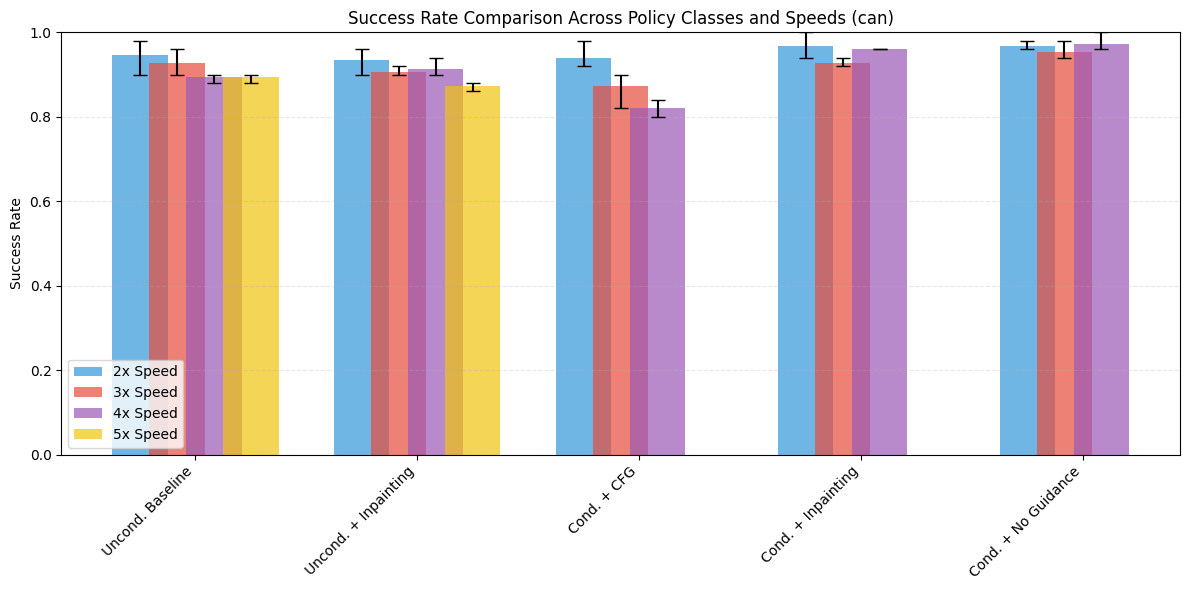

In [30]:
# Create the plot
fig = plot_success_rate_comparison(
    speed_to_pkl_files,
    figsize=(12, 6),
    save_path="success_rate_comparison.png",
    task=task
)

100%|██████████| 3/3 [00:00<00:00,  3.35it/s]


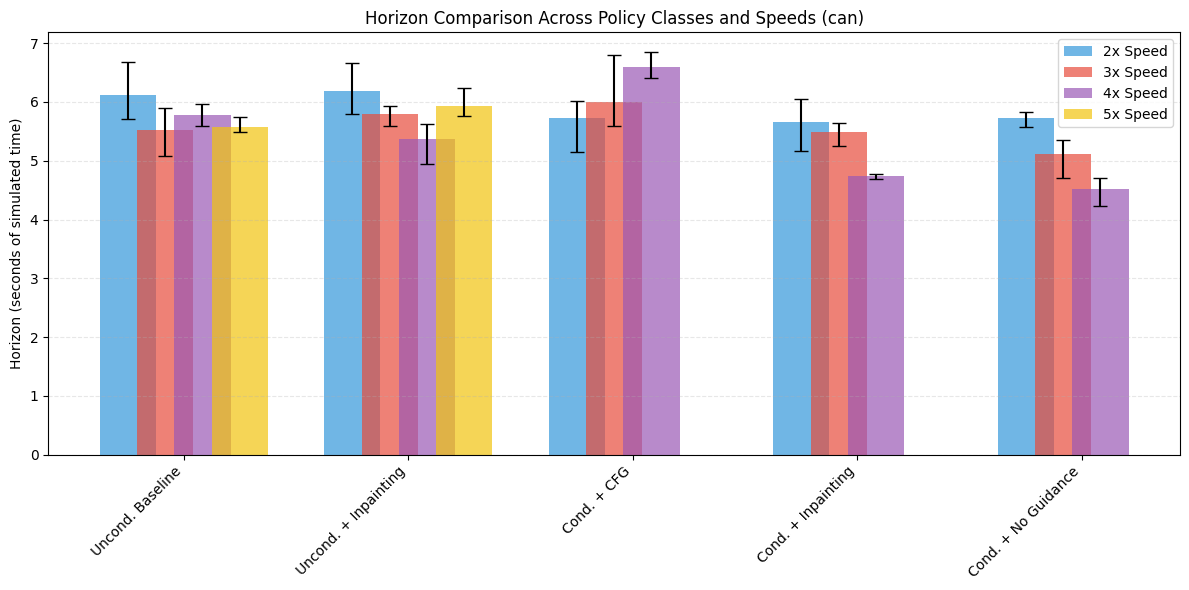

In [31]:
# Create the plot
fig = plot_horizon_comparison(
    speed_to_pkl_files,
    figsize=(12, 6),
    save_path="horizon_comparison.png",
    task=task
)

In [32]:
# This block evaluates the success rate of each method

cfg_results = speed_to_pkl_files["3x"]["cond_cfg"] for example

# cfg (best hparam)
analyzer= DemoEvalSuite(cfg_results, Metrics.success_eval_fn, metric_name="success")

# inpainting (best hparam)
analyzer_inp = DemoEvalSuite(cfg_inp_results, Metrics.success_eval_fn, metric_name="success")

# cfg + bl
analyzer_cfg_bl = DemoEvalSuite(cfg_bl_results, Metrics.success_eval_fn, metric_name="success")

# baseline
analyzer_bl = DemoEvalSuite(bl_results, Metrics.success_eval_fn, metric_name="success")

analyzer_inp_bl = DemoEvalSuite(inp_bl_results, Metrics.success_eval_fn, metric_name="success")

# This blocks give you success rate
print(f"CFG Best: Min {analyzer.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"CFG + Inpainting: Min {analyzer_inp.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_inp.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_inp.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"CFG + BL: Min {analyzer_cfg_bl.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_cfg_bl.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_cfg_bl.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"BL: Min {analyzer_bl.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_bl.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_bl.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"Inpainting + BL: Min {analyzer_inp_bl.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_inp_bl.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_inp_bl.df.groupby(by='result_idx')['success'].mean().max():.2f}")

import matplotlib.pyplot as plt
import numpy as np

# Data preparation
labels = [
    'Uncond. Baseline',
    'Uncond. + Inpainting',
    'Cond. + CFG',
    'Cond. + Inpainting',
    'Cond. + No Guidance'
]

# Data structure: [min, mean, max] for each speed
data_3x = [
    [0.30, 0.35, 0.38],  # Baseline
    [0.24, 0.26, 0.29],  # Uncond + Inpainting
    [0.47, 0.49, 0.51],  # Cond + CFG
    [0.54, 0.56, 0.59],  # Cond + Inpainting
    [0.65, 0.69, 0.74]   # Cond + No guidance
]

data_2x = [
    [0.55, 0.59, 0.67],
    [0.53, 0.55, 0.59],
    [0.58, 0.63, 0.67],
    [0.70, 0.76, 0.80],
    [0.74, 0.78, 0.80]
]

data_1x = [
    [0.77, 0.82, 0.87],
    [0.80, 0.82, 0.90],  # No data for 1x
    [0.69, 0.76, 0.83],
    [0.81, 0.85, 0.88],
    [0.81, 0.85, 0.91]
]

# Create figure
plt.figure(figsize=(12, 6))

# Position calculations
x = np.arange(len(labels))
width = 0.25  # Width of bars

# Plot bars for each speed
for i, (speed_data, offset, color, label) in enumerate([
    (data_1x, -width, '#2ecc71', '1x Speed'),
    (data_2x, 0, '#3498db', '2x Speed'),
    (data_3x, width, '#e74c3c', '3x Speed')
]):
    means = [d[1] if d[1] is not None else np.nan for d in speed_data]
    yerr_minus = [d[1] - d[0] if d[1] is not None else np.nan for d in speed_data]
    yerr_plus = [d[2] - d[1] if d[1] is not None else np.nan for d in speed_data]
    
    plt.bar(x + offset, means, width, label=label, color=color, alpha=0.7)
    plt.errorbar(x + offset, means, yerr=[yerr_minus, yerr_plus], 
                fmt='none', color='black', capsize=5)

# Customize plot
plt.ylabel('Success Rate')
plt.title('Success Rate Comparison Across Policy Classes and Speeds')
plt.xticks(x, labels, rotation=45, ha='right', fontsize=20)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend()

# Set y-axis limits
plt.ylim(0, 1.0)

# Adjust layout
plt.tight_layout()

plt.show()

SyntaxError: invalid syntax (2295104159.py, line 3)